In [2]:
# IMPORTAÇÃO DOS DADOS LIMPOS

import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/global-inequality-cleaned.csv")

In [3]:
# VISÃO GERAL

df.head()

,country,year,gini,region,gdp_per_capita,idh,education
0,Albania,1996,0.270103,Europe,5563.793,0.647,7.623845
1,Albania,2002,0.317390,Europe,7590.490,0.697,8.885714
2,Albania,2005,0.305957,Europe,8964.318,0.723,9.082857
3,Albania,2008,0.299847,Europe,11056.352,0.749,9.280000
4,Albania,2012,0.289605,Europe,12463.570,0.790,10.030000


In [4]:
df.describe()

,year,gini,gdp_per_capita,idh,education
count,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000
mean,2009.455639,0.372157,28240.509023,0.762644,9.455188
std,8.644919,0.086800,24042.231970,0.146483,3.067359
min,1990.000000,0.201866,562.857500,0.222000,0.808391
25%,2004.000000,0.308007,9885.680500,0.682000,7.390000
50%,2010.000000,0.352277,20470.494000,0.789000,10.207999
75%,2017.000000,0.420501,43121.937000,0.883500,11.997218
max,2023.000000,0.710505,138677.970000,0.970000,14.260000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         1995 non-null   object 
 1   year            1995 non-null   int64  
 2   gini            1995 non-null   float64
 3   region          1995 non-null   object 
 4   gdp_per_capita  1995 non-null   float64
 5   idh             1995 non-null   float64
 6   education       1995 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 109.2+ KB


In [ ]:
# CORRELAÇÃO

corr = df[['gini', 'gdp_per_capita', 'idh', 'education']].corr()
corr

,gini,gdp_per_capita,idh,education
gini,1.000000,-0.452616,-0.464554,-0.530027
gdp_per_capita,-0.452616,1.000000,0.773378,0.656131
idh,-0.464554,0.773378,1.000000,0.898574
education,-0.530027,0.656131,0.898574,1.000000


In [ ]:
# REGRESSÃO LINEAR - GINI, GDP

import statsmodels.api as sm

X = df['gdp_per_capita']
y = df['gini'] # VARIÁVEL DEPENDENTE (O QUE QUEREMOS EXPLICAR)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit() # REGRESSÃO LINEAR SIMPLES (ORDINARY LEAST SQUARES)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     513.5
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          2.44e-101
Time:                        19:44:55   Log-Likelihood:                 2274.5
No. Observations:                1995   AIC:                            -4545.
Df Residuals:                    1993   BIC:                            -4534.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.4183      0.003    156.

In [8]:
# REGRESSÃO LINEAR - GINI, EDUCATION

X = sm.add_constant(df['education'])
y = df['gini']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     778.6
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          6.32e-145
Time:                        19:53:19   Log-Likelihood:                 2374.8
No. Observations:                1995   AIC:                            -4746.
Df Residuals:                    1993   BIC:                            -4734.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5140      0.005     96.197      0.0

In [9]:
# REGRESSÃO LINEAR - GINI, IDH

X = sm.add_constant(df['idh'])
y = df['gini']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     548.5
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          2.37e-107
Time:                        19:54:25   Log-Likelihood:                 2288.3
No. Observations:                1995   AIC:                            -4573.
Df Residuals:                    1993   BIC:                            -4561.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5821      0.009     63.770      0.0

<Axes: xlabel='year'>

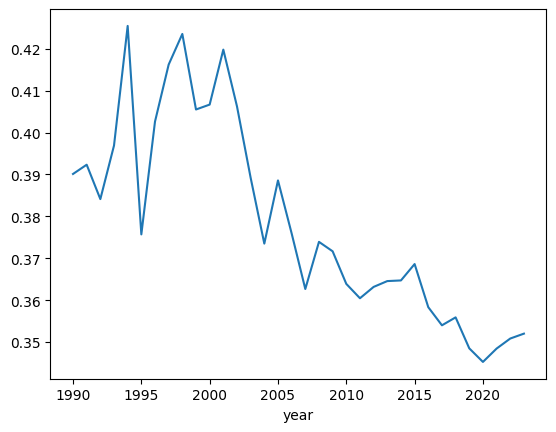

In [10]:
# ANÁLISE TEMPORAL - EVOLUCÃO GLOBAL

trend = df.groupby('year')['gini'].mean()

trend.plot()

In [24]:
# ANÁLISE TEMPORAL - POR REGIÃO

trend_region = df.groupby(['year','region'])['gini'].mean().reset_index()

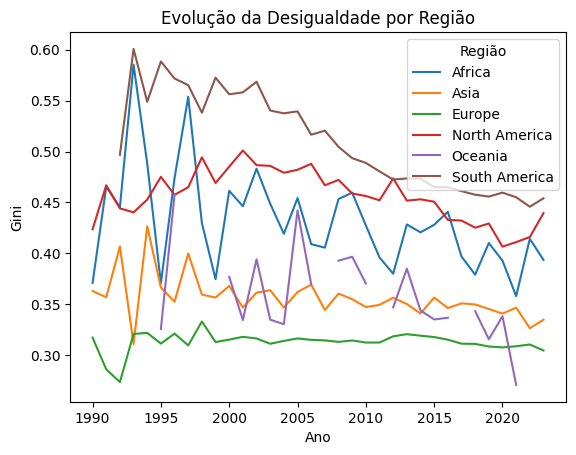

In [25]:
import matplotlib.pyplot as plt

pivot = trend_region.pivot(index='year', columns='region', values='gini')

pivot.plot()

plt.title('Evolução da Desigualdade por Região')
plt.xlabel('Ano')
plt.ylabel('Gini')
plt.legend(title='Região')
plt.show()

In [27]:
# INSIGHTS POR REGIÃO

df.groupby('region')['gini'].mean().sort_values(ascending=False)

region
South America    0.498195
North America    0.458746
Africa           0.425981
Oceania          0.363752
Asia             0.353259
Europe           0.313356
Name: gini, dtype: float64

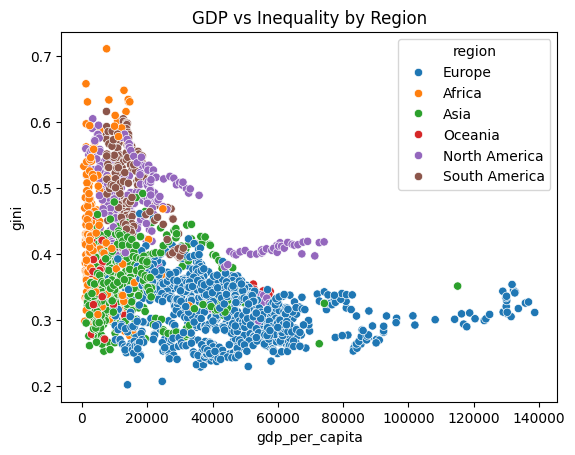

In [30]:
# RELAÇÕES VISUAIS

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='gdp_per_capita',
    y='gini',
    hue='region'
)

plt.title('GDP vs Inequality by Region')
plt.show()